# Thai Character Model Lab — เทรนและค้นหา config กลาง

Notebook นี้มี pipeline จริง: **ตรวจข้อมูล → ล็อก split → Custom CNN / timm benchmark → ablation → Optuna → เทรนเต็ม → leaderboard → inference**

**เริ่มใช้งาน:** เปิด notebook จาก repo นี้ด้วย Jupyter หรือ VS Code, เลือก Python kernel แล้วแก้ cell ตั้งค่าด้านล่าง จากนั้น **Run All** ข้อมูลเป็นภาพในโฟลเดอร์แยกคลาส (72 คลาส) ใช้ `THAI_CHAR_DATA_DIR` / `THAI_CHAR_DRIVE_URL` ใน `.env` เดิมได้ ไม่ต้องเขียน trainer เพิ่ม

บน **Colab** เลือก GPU และ clone/upload **ทั้ง repo** ก่อน จากนั้นระบุ `REPO_PATH` เป็นโฟลเดอร์ repo; ถ้าจะเก็บผลข้าม session ให้ mount Drive แล้วตั้ง `OUTPUT_ROOT` และ `SPLIT_PATH` ไปที่ Drive ข้อมูลภาพควร cache บนเครื่อง runtime เพื่อให้อ่านเร็ว

- `smoke`: ภาพจำลอง 3 คลาส, Custom CNN + ResNet-18 ไม่ดาวน์โหลด pretrained weights — ตรวจระบบเท่านั้น
- `quick`: benchmark 6 epochs, HPO 8 trials × 6 epochs, ยืนยัน top 2 + control ที่ 20 epochs / 1 seed
- `full` (ค่าเริ่มต้น): benchmark 12 epochs, HPO 12 trials × 8 epochs, ยืนยัน top 2 + control ที่ 30 epochs / 2 seeds

เวลาจริงขึ้นกับจำนวนภาพและ GPU; `full` อาจใช้หลายชั่วโมง มี log ราย epoch และบันทึกผลลงดิสก์ ใช้ `quick` เพื่อลองครั้งแรก **“best” คือดีที่สุดใน candidates/search space และ validation ชุดนี้ ไม่ใช่รับประกัน global optimum หรือคะแนน official test**


In [1]:
from pathlib import Path
import sys

# ---------- แก้เฉพาะส่วนนี้เพื่อเริ่ม ----------
MODE = "full"                      # "smoke", "quick", "full"
REPO_PATH = ""                     # ว่าง = ค้นหาจาก cwd และ parent; Colab เช่น /content/project
DATA_PATH = ""                     # ว่าง = อ่าน .env หรือ data/raw; เช่น /content/thai_images
SPLIT_PATH = ""                    # ว่าง = data/splits; แชร์ CSV + JSON ทั้งโฟลเดอร์ให้ทีม
OUTPUT_ROOT = ""                   # ว่าง = results/model_search; Colab ใช้ path บน mounted Drive
DOWNLOAD_IF_MISSING = True         # ดาวน์โหลด public Drive folder ที่ตั้งไว้ ถ้า cache ยังว่าง
LABEL_LEVEL = 1                    # root/class/image.png; ถ้า root/class/source/image.png ใช้ 2
EXPECTED_CLASSES = 72
ARCHITECTURES = ["resnet18", "efficientnet_b0", "mobilenetv3_large_100"]
IMAGE_SIZE = 224
BATCH_SIZE = 32                    # ถ้า GPU OOM ลดเป็น 16 แล้วเริ่ม comparison ใหม่ทุกโมเดล
PAD_VALUE = 255                    # ตรวจตัวอย่างก่อน: 255 = ขาว, 0 = ดำ
DEVICE = "auto"                    # CUDA → Apple MPS → CPU หรือระบุ "cuda" / "cpu"
SEED = 42

candidates = [Path(REPO_PATH).expanduser()] if REPO_PATH else [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next((p.resolve() for p in candidates if (p / "src/train.py").is_file()), None)
if REPO_ROOT is None:
    raise RuntimeError("Clone/upload ทั้ง repo แล้วตั้ง REPO_PATH ให้ชี้โฟลเดอร์ที่มี src/train.py")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
BUDGETS = {
    "smoke": dict(benchmark=2, hpo_epochs=2, trials=2, final_epochs=2, seeds=(42,)),
    "quick": dict(benchmark=6, hpo_epochs=6, trials=8, final_epochs=20, seeds=(42,)),
    "full": dict(benchmark=12, hpo_epochs=8, trials=12, final_epochs=30, seeds=(42, 123)),
}
BUDGET = BUDGETS[MODE]
print("Repository:", REPO_ROOT)
print("Mode / budget:", MODE, BUDGET)


Repository: /Users/thawaree.kha/kmitl-deeplearn-project1
Mode / budget: full {'benchmark': 12, 'hpo_epochs': 8, 'trials': 12, 'final_epochs': 30, 'seeds': (42, 123)}


## 1. ติดตั้ง dependencies ใน kernel ปัจจุบัน
รันครั้งแรกต้องมีอินเทอร์เน็ต ถ้า kernel มี packages ครบจะข้ามการติดตั้ง ไม่ติดตั้ง torch ใหม่ทับ CUDA ที่ Colab เตรียมไว้โดยไม่จำเป็น หาก import error หลังติดตั้ง ให้ restart kernel แล้ว Run All อีกครั้ง


In [2]:
import importlib.util
import subprocess

required = ["torch", "torchvision", "timm", "optuna", "numpy", "pandas", "sklearn", "matplotlib", "PIL", "gdown"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing:
    print("Installing missing training dependencies:", missing)
    subprocess.run([sys.executable, "-m", "pip", "install", "-r",
                    str(REPO_ROOT / "requirements-training.txt")], check=True)
else:
    print("Training dependencies are available")

import json
import shutil
from dataclasses import asdict, replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from IPython.display import display
from src.audit import audit_dataset, DEFAULT_EXTENSIONS, image_paths
from src.paths import configured_data_dir
from src.split import prepare_split, read_rows
from src.train import TrainConfig, choose_device, make_transform, save_json
from src.search import run_benchmark, run_ablations, config_from_receipt, tune, confirm
from src.inference import Predictor

print("PyTorch:", torch.__version__, "device:", choose_device(DEVICE))
if choose_device(DEVICE).type == "cpu" and MODE != "smoke":
    print("CPU ทำงานได้แต่ full search จะช้า: ใช้ GPU หรือ MODE='smoke' เพื่อตรวจระบบก่อน")


Training dependencies are available
PyTorch: 2.14.0 device: mps


/Users/thawaree.kha/kmitl-deeplearn-project1/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. เตรียม cache และตรวจข้อมูล
`smoke` สร้างข้อมูลจำลองใน output ของตัวเอง ไม่ใช้ข้อมูลจริง ส่วนโหมดจริงอ่าน path ที่ตั้งไว้หรือดาวน์โหลดจาก public Drive folder ใน `.env` หาก Drive เป็น private ให้ mount Drive เองแล้วระบุ `DATA_PATH`

รองรับภาพที่แตกไฟล์แล้ว ไม่แตก ZIP อัตโนมัติ หลังดาวน์โหลดล้มเหลวจะหยุดเพื่อไม่ใช้ cache ที่โหลดไม่ครบ


In [3]:
OUTPUT_BASE = Path(OUTPUT_ROOT).expanduser().resolve() if OUTPUT_ROOT else REPO_ROOT / "results/model_search"
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)
if MODE == "smoke":
    DATA_DIR = OUTPUT_BASE / "smoke_fixture/images"
    # เป็นข้อมูลทดสอบระบบเท่านั้น คะแนนจากภาพเหล่านี้ไม่มีความหมายด้านคุณภาพโมเดล
    rng = np.random.default_rng(42)
    for label in range(3):
        folder = DATA_DIR / f"synthetic_{label}"
        folder.mkdir(parents=True, exist_ok=True)
        for index in range(10):
            path = folder / f"{index:03d}.png"
            if not path.exists():
                pixels = rng.integers(0, 40, (40, 32, 3), dtype=np.uint8)
                pixels[:, :, label] += 180
                Image.fromarray(pixels).save(path)
    SPLIT_DIR = OUTPUT_BASE / "smoke_fixture/splits"
    EXPECTED_CLASSES = 3
    LABEL_LEVEL = 1
    IMAGE_SIZE, BATCH_SIZE, ARCHITECTURES = 32, 8, ["resnet18"]
else:
    DATA_DIR = (Path(DATA_PATH).expanduser() if DATA_PATH else configured_data_dir()).resolve()
    SPLIT_DIR = Path(SPLIT_PATH).expanduser().resolve() if SPLIT_PATH else REPO_ROOT / "data/splits"
    marker = DATA_DIR / ".download_incomplete"
    if marker.exists():
        raise RuntimeError(f"Previous download incomplete: {DATA_DIR}. Restore a complete cache before removing the marker.")
    if not list(image_paths(DATA_DIR, DEFAULT_EXTENSIONS)):
        if not DOWNLOAD_IF_MISSING:
            raise FileNotFoundError("No images found. Set DATA_PATH to the extracted image folder.")
        if DATA_DIR.exists() and any(DATA_DIR.iterdir()):
            raise RuntimeError("DATA_DIR is non-empty but contains no images. Check for ZIP files or a wrong path.")
        # The downloader refuses non-empty directories; marker goes in only after failure.
        try:
            subprocess.run([sys.executable, "-m", "src.download_data", "--output-dir", str(DATA_DIR)],
                           cwd=REPO_ROOT, check=True)
        except BaseException:
            DATA_DIR.mkdir(parents=True, exist_ok=True)
            marker.touch()
            raise
AUDIT_DIR = OUTPUT_BASE / MODE / "audit"
report = audit_dataset(DATA_DIR, AUDIT_DIR, LABEL_LEVEL, DEFAULT_EXTENSIONS)
display(pd.Series({k: v for k, v in report.items() if not isinstance(v, (dict, list))}))
if report["corrupt_images"] or report["label_errors"]:
    raise RuntimeError(f"Review corrupt_images.csv / label_errors.csv in {AUDIT_DIR}, fix data and rerun.")
print("Data:", DATA_DIR)
print("Audit:", AUDIT_DIR)


created_at_utc                                       2026-09-16T07:25:02.709488+00:00
data_dir                            /Users/thawaree.kha/kmitl-deeplearn-project1/d...
label_level                                                                         1
discovered_supported_files                                                      62707
valid_images                                                                    62707
corrupt_images                                                                      0
label_errors                                                                        0
class_count                                                                        72
minimum_images_per_class                                                            1
maximum_images_per_class                                                         5025
imbalance_ratio_max_over_min                                                   5025.0
exact_duplicate_groups                                

Data: /Users/thawaree.kha/kmitl-deeplearn-project1/data/raw
Audit: /Users/thawaree.kha/kmitl-deeplearn-project1/results/model_search/full/audit


## 3. ล็อก split 80/20 และ label mapping
แยกแต่ละคลาสโดยใช้กลุ่ม SHA-256 ของภาพซ้ำ กลุ่มเดียวกันจะไม่ข้าม train/validation สัดส่วนอาจไม่ใช่ 20% พอดีเพราะกลุ่มแบ่งไม่ได้ ทุกคลาสต้องมีอย่างน้อย 2 กลุ่ม และภาพเดียวกันที่มีคนละ label ต้องแก้ก่อน

ไฟล์ split เก็บ relative paths จึงส่งให้เพื่อนใช้ต่างเครื่องได้ รันซ้ำจะตรวจ fingerprint และใช้ split เดิม หากข้อมูลหรือ seed เปลี่ยนต้องกำหนด split directory ใหม่อย่างชัดเจน **ยังไม่ตรวจ near-duplicate / กลุ่มผู้เขียน / font source** ต้องตรวจเพิ่มเติมก่อนอ้างผล generalization


{
  "dataset_hash": "f2b6af3a6341c6cf407b3a6290db804da156afedac618fbc958f0c3ba943818a",
  "seed": 42,
  "val_fraction": 0.2,
  "algorithm": "sha256-label-greedy-v2",
  "conflicting_label_policy": "exclude",
  "excluded_conflicting_hashes": 11,
  "excluded_conflicting_images": 23,
  "split_hash": "e90d3777438a02f85b75c82f6e579d1d97b6332a4255bf4324daf32089700265",
  "train_images": 50142,
  "val_images": 12542,
  "source_images": 62707,
  "included_images": 62684,
  "actual_val_fraction": 0.20008295577818902,
  "num_classes": 72,
  "train_only_classes": [
    "163",
    "177"
  ]
}


split,train,validation
class,,
161,1561,390
162,1084,271
163,1,0
164,1158,289
167,862,216
...,...,...
245,14,3
246,10,2
247,3,1


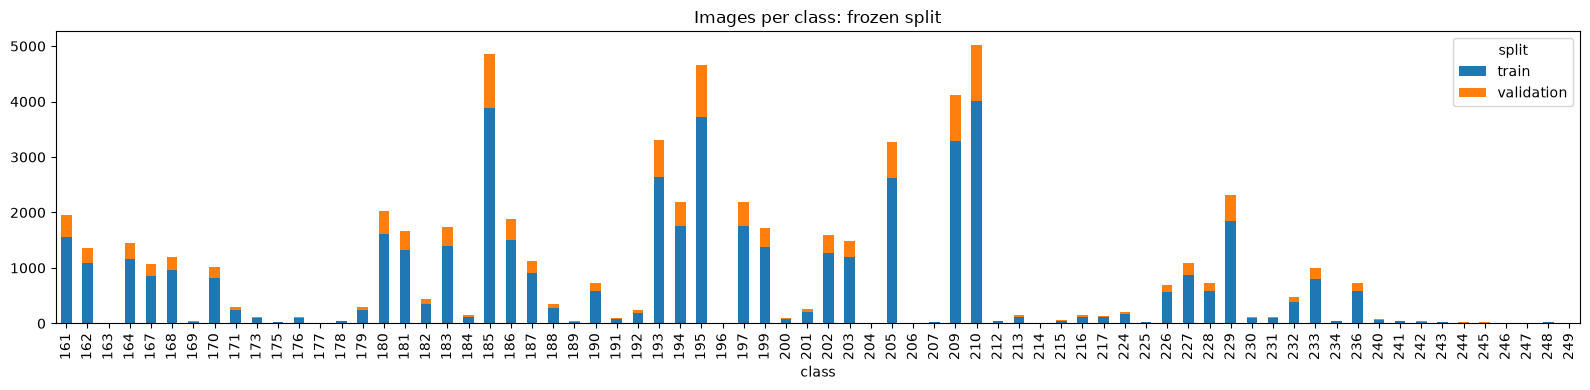

Share all four files from: /Users/thawaree.kha/kmitl-deeplearn-project1/data/splits
Experiment output: /Users/thawaree.kha/kmitl-deeplearn-project1/results/model_search/full/e90d3777438a


In [4]:
split_meta = prepare_split(DATA_DIR, AUDIT_DIR, SPLIT_DIR, seed=SEED, expected_classes=EXPECTED_CLASSES)
print(json.dumps(split_meta, indent=2))
OUTPUT_DIR = OUTPUT_BASE / MODE / split_meta["split_hash"][:12]
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
train_rows, val_rows = read_rows(SPLIT_DIR / "train.csv"), read_rows(SPLIT_DIR / "val.csv")
counts = pd.crosstab(pd.Series([r["label"] for r in train_rows + val_rows], name="class"),
                     pd.Series(["train"] * len(train_rows) + ["validation"] * len(val_rows), name="split"))
display(counts)
counts.plot.bar(stacked=True, figsize=(16, 4), title="Images per class: frozen split")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=140)
plt.show()
print("Share all four files from:", SPLIT_DIR)
print("Experiment output:", OUTPUT_DIR)


## 4. ตรวจภาพและ preprocessing กลาง
ทุก backbone ใช้ resize + padding ที่รักษาสัดส่วน, RGB, ImageNet mean/std ชุดเดียวกัน เพื่อควบคุมการเปรียบเทียบ (อาจต่างจาก preprocessing ที่เหมาะที่สุดของ pretrained weights บางชุด) นี่เป็น recipe ของ notebook นี้; ไม่ได้อ่าน YAML E0 เดิมที่วางแผนใช้ train statistics

Augmentation ใช้ rotation ±5°, translation 3%, scale 0.95–1.05 เฉพาะ train ไม่มี flip หรือ crop แรง ตรวจภาพก่อนเปิดใช้จริง


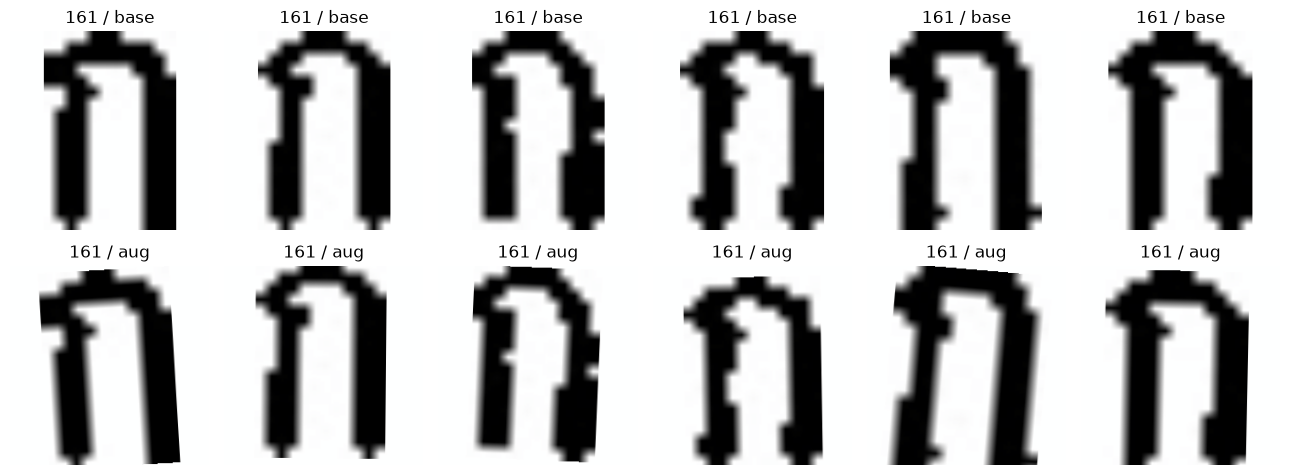

In [5]:
BASE = TrainConfig(seed=SEED, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                   epochs=BUDGET["benchmark"], freeze_epochs=0 if MODE == "smoke" else 2,
                   pretrained=MODE != "smoke", pad_value=PAD_VALUE, device=DEVICE,
                   num_workers=0, patience=5)
fig, axes = plt.subplots(2, 6, figsize=(13, 5))
preview = make_transform(BASE)
augmented_preview = make_transform(replace(BASE, augmentation=True), training=True)
for i, row in enumerate(train_rows[:6]):
    with Image.open(DATA_DIR / row["path"]) as source:
        original = source.convert("RGB")
    for j, transform in enumerate([preview, augmented_preview]):
        tensor = transform(original)
        pixels = tensor.permute(1, 2, 0).numpy() * np.array(BASE.std) + np.array(BASE.mean)
        axes[j, i].imshow(pixels.clip(0, 1))
        axes[j, i].set_title(f"{row['label']} / {'aug' if j else 'base'}")
for axis in axes.flat:
    axis.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "preprocessing_preview.png", dpi=140)
plt.show()
save_json(OUTPUT_DIR / "base_config.json", asdict(BASE))


## 5. เทรน baseline และค้นหา architecture
ค่าอื่นคงที่ เปลี่ยนเฉพาะ architecture ในกลุ่ม pretrained; Custom CNN ฝึกจากศูนย์เป็น reference ขั้น transfer learning ฝึก classifier ก่อน 2 epochs แล้วปลดทั้ง backbone โดยลด learning rate มี AdamW, ReduceLROnPlateau, gradient clipping, early stopping และ CUDA AMP

เรียงคะแนนด้วย validation macro F1 แล้ว accuracy โมเดลที่ได้คะแนนสูงสุดเป็นผู้ชนะ screening แม้เป็น Custom CNN ก็ใช้ต่อได้ เพิ่มโมเดลใหม่ด้วยชื่อจาก `timm` ใน `ARCHITECTURES` (ต้องรองรับ input size และ `get_classifier()`)

**กรณี OOM:** ลด `BATCH_SIZE` แล้วรัน comparison ทั้งชุดใหม่ ไม่มีการลด batch เฉพาะบางโมเดลอัตโนมัติ


In [6]:
benchmark = run_benchmark(BASE, ARCHITECTURES, DATA_DIR, SPLIT_DIR, OUTPUT_DIR)
display(benchmark[["backbone", "val_accuracy", "val_macro_f1", "best_epoch", "parameter_count", "training_seconds"]])
BACKBONE_WINNER = config_from_receipt(benchmark.iloc[0].to_dict())
print("Architecture selected:", BACKBONE_WINNER.architecture)


benchmark-custom_cnn-8fcc4acf92 | 1/12 | loss=1.4307 val_acc=0.7889 macro_f1=0.4054
benchmark-custom_cnn-8fcc4acf92 | 2/12 | loss=0.6827 val_acc=0.6491 macro_f1=0.3691
benchmark-custom_cnn-8fcc4acf92 | 3/12 | loss=0.4986 val_acc=0.8886 macro_f1=0.5869
benchmark-custom_cnn-8fcc4acf92 | 4/12 | loss=0.3980 val_acc=0.9105 macro_f1=0.6813
benchmark-custom_cnn-8fcc4acf92 | 5/12 | loss=0.3431 val_acc=0.9295 macro_f1=0.7226
benchmark-custom_cnn-8fcc4acf92 | 6/12 | loss=0.2966 val_acc=0.9255 macro_f1=0.7055
benchmark-custom_cnn-8fcc4acf92 | 7/12 | loss=0.2609 val_acc=0.9411 macro_f1=0.7582
benchmark-custom_cnn-8fcc4acf92 | 8/12 | loss=0.2428 val_acc=0.9420 macro_f1=0.7679
benchmark-custom_cnn-8fcc4acf92 | 9/12 | loss=0.2225 val_acc=0.9416 macro_f1=0.8093
benchmark-custom_cnn-8fcc4acf92 | 10/12 | loss=0.2078 val_acc=0.9406 macro_f1=0.8189
benchmark-custom_cnn-8fcc4acf92 | 11/12 | loss=0.1919 val_acc=0.9630 macro_f1=0.8395
benchmark-custom_cnn-8fcc4acf92 | 12/12 | loss=0.1815 val_acc=0.9522 macro

benchmark-efficientnet_b0-b754ba7232 | 1/12 | loss=0.4954 val_acc=0.9442 macro_f1=0.7851
benchmark-efficientnet_b0-b754ba7232 | 2/12 | loss=0.1660 val_acc=0.9517 macro_f1=0.8562
benchmark-efficientnet_b0-b754ba7232 | 3/12 | loss=0.2092 val_acc=0.9734 macro_f1=0.9185
benchmark-efficientnet_b0-b754ba7232 | 4/12 | loss=0.0692 val_acc=0.9739 macro_f1=0.9282
benchmark-efficientnet_b0-b754ba7232 | 5/12 | loss=0.0499 val_acc=0.9766 macro_f1=0.9294
benchmark-efficientnet_b0-b754ba7232 | 6/12 | loss=0.0398 val_acc=0.9737 macro_f1=0.9289
benchmark-efficientnet_b0-b754ba7232 | 7/12 | loss=0.0322 val_acc=0.9797 macro_f1=0.9368
benchmark-efficientnet_b0-b754ba7232 | 8/12 | loss=0.0247 val_acc=0.9762 macro_f1=0.9354
benchmark-efficientnet_b0-b754ba7232 | 9/12 | loss=0.0224 val_acc=0.9758 macro_f1=0.9273
benchmark-efficientnet_b0-b754ba7232 | 10/12 | loss=0.0196 val_acc=0.9750 macro_f1=0.9243
benchmark-efficientnet_b0-b754ba7232 | 11/12 | loss=0.0080 val_acc=0.9838 macro_f1=0.9333
benchmark-efficient

,backbone,val_accuracy,val_macro_f1,best_epoch,parameter_count,training_seconds
0,mobilenetv3_large_100,0.977675,0.948176,10,4294264,6002.479271
1,efficientnet_b0,0.979748,0.936787,7,4099780,11558.574578
2,resnet18,0.983735,0.924278,11,11213448,5433.352743
3,custom_cnn,0.963004,0.839460,11,407880,4145.168713


Architecture selected: mobilenetv3_large_100


## 6. Ablation: augmentation และ class weights
ทดลอง augmentation เทียบกับ control ก่อน แล้วทดลอง capped square-root inverse-frequency class weights บน policy ที่ชนะ ใช้จำนวนภาพ **train เท่านั้น** คำนวณ weights ไม่ผสม sampler/oversampling เพิ่ม การทดลองแต่ละขั้นเปลี่ยนหนึ่งปัจจัย


In [7]:
ablations = run_ablations(BACKBONE_WINNER, DATA_DIR, SPLIT_DIR, OUTPUT_DIR)
POLICY_WINNER = config_from_receipt(ablations.iloc[0].to_dict())
display(ablations[["run_id", "val_accuracy", "val_macro_f1", "minimum_per_class_recall"]])
print("Selected augmentation:", POLICY_WINNER.augmentation, "class weights:", POLICY_WINNER.class_weights)


Reusing completed run: benchmark-mobilenetv3_large_100-f5e87269b3
ablation-mobilenetv3_large_100-46b80c1b26 | 1/12 | loss=0.5322 val_acc=0.9168 macro_f1=0.7616
ablation-mobilenetv3_large_100-46b80c1b26 | 2/12 | loss=0.2098 val_acc=0.9245 macro_f1=0.8018
ablation-mobilenetv3_large_100-46b80c1b26 | 3/12 | loss=0.2129 val_acc=0.9742 macro_f1=0.9066
ablation-mobilenetv3_large_100-46b80c1b26 | 4/12 | loss=0.0900 val_acc=0.9747 macro_f1=0.9246
ablation-mobilenetv3_large_100-46b80c1b26 | 5/12 | loss=0.0735 val_acc=0.9699 macro_f1=0.9262
ablation-mobilenetv3_large_100-46b80c1b26 | 6/12 | loss=0.0662 val_acc=0.9727 macro_f1=0.9248
ablation-mobilenetv3_large_100-46b80c1b26 | 7/12 | loss=0.0564 val_acc=0.9779 macro_f1=0.9374
ablation-mobilenetv3_large_100-46b80c1b26 | 8/12 | loss=0.0508 val_acc=0.9763 macro_f1=0.9214
ablation-mobilenetv3_large_100-46b80c1b26 | 9/12 | loss=0.0462 val_acc=0.9752 macro_f1=0.9355
ablation-mobilenetv3_large_100-46b80c1b26 | 10/12 | loss=0.0422 val_acc=0.9796 macro_f1=

,run_id,val_accuracy,val_macro_f1,minimum_per_class_recall
0,ablation-mobilenetv3_large_100-824a2f4603,0.980386,0.953853,0.0
1,benchmark-mobilenetv3_large_100-f5e87269b3,0.977675,0.948176,0.0
2,ablation-mobilenetv3_large_100-46b80c1b26,0.979589,0.942239,0.0


Selected augmentation: False class weights: True


## 7. Optuna — จูน 4 ค่าและตัด trial ที่แนวโน้มไม่ดี
ตรึง architecture, augmentation, class weights, split, batch และขนาดภาพ จูน `head_lr`, `finetune_lr`, `weight_decay`, `dropout` ด้วย TPE และ MedianPruner เลือกตาม best validation macro F1

SQLite เก็บผลถาวร รันซ้ำจะทำต่อให้ครบ **จำนวน trials รวม** ที่ตั้งไว้ Completed run เดิมใช้ซ้ำได้หาก config/split/code/environment ตรงกัน การรันที่ขัดจังหวะจะเริ่ม train ใหม่ ไม่ได้ resume optimizer กลาง epoch; trial ที่ขัดจังหวะอาจยังแสดง RUNNING ใน SQLite แต่ไม่ถูกนำมาคัดเลือก การรันต่อไม่ได้รับประกันลำดับ TPE เหมือนการรันต่อเนื่อง

สำหรับ Custom CNN หรือกรณีไม่ใช้ head warmup ระบบจะตัด learning rate ที่ไม่ได้ใช้จริงออกจาก search space อัตโนมัติ เหลือ 3 มิติ


In [8]:
HPO_BASE = replace(POLICY_WINNER, epochs=BUDGET["hpo_epochs"])
study = tune(HPO_BASE, DATA_DIR, SPLIT_DIR, OUTPUT_DIR, n_trials=BUDGET["trials"])
display(study.trials_dataframe())
print("Best screening trial:", study.best_trial.number)
print("Best screening macro F1:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-09-17 02:43:13,862] A new study created in RDB with name: thai-search-2d9b63e0cf22fa7f


hpo-mobilenetv3_large_100-6f9b514160 | 1/8 | loss=0.6379 val_acc=0.9124 macro_f1=0.7041
hpo-mobilenetv3_large_100-6f9b514160 | 2/8 | loss=0.2174 val_acc=0.9337 macro_f1=0.7951
hpo-mobilenetv3_large_100-6f9b514160 | 3/8 | loss=0.1642 val_acc=0.9778 macro_f1=0.9073
hpo-mobilenetv3_large_100-6f9b514160 | 4/8 | loss=0.0497 val_acc=0.9754 macro_f1=0.9432
hpo-mobilenetv3_large_100-6f9b514160 | 5/8 | loss=0.0362 val_acc=0.9805 macro_f1=0.9414
hpo-mobilenetv3_large_100-6f9b514160 | 6/8 | loss=0.0294 val_acc=0.9797 macro_f1=0.9476
hpo-mobilenetv3_large_100-6f9b514160 | 7/8 | loss=0.0222 val_acc=0.9813 macro_f1=0.9456
hpo-mobilenetv3_large_100-6f9b514160 | 8/8 | loss=0.0190 val_acc=0.9792 macro_f1=0.9329


[I 2026-09-17 03:43:31,493] Trial 0 finished with value: 0.9475998745362335 and parameters: {'head_lr': 0.00035747129226002455, 'finetune_lr': 8.927180304353627e-05, 'weight_decay': 0.00015702970884055374, 'dropout': 0.3394633936788147}. Best is trial 0 with value: 0.9475998745362335.


hpo-mobilenetv3_large_100-15eae455e5 | 1/8 | loss=0.9347 val_acc=0.8748 macro_f1=0.5560
hpo-mobilenetv3_large_100-15eae455e5 | 2/8 | loss=0.3459 val_acc=0.9127 macro_f1=0.6979
hpo-mobilenetv3_large_100-15eae455e5 | 3/8 | loss=0.6002 val_acc=0.9489 macro_f1=0.7018
hpo-mobilenetv3_large_100-15eae455e5 | 4/8 | loss=0.1278 val_acc=0.9682 macro_f1=0.8046
hpo-mobilenetv3_large_100-15eae455e5 | 5/8 | loss=0.0820 val_acc=0.9756 macro_f1=0.8581
hpo-mobilenetv3_large_100-15eae455e5 | 6/8 | loss=0.0622 val_acc=0.9780 macro_f1=0.8939
hpo-mobilenetv3_large_100-15eae455e5 | 7/8 | loss=0.0502 val_acc=0.9808 macro_f1=0.9166
hpo-mobilenetv3_large_100-15eae455e5 | 8/8 | loss=0.0418 val_acc=0.9746 macro_f1=0.9152


[I 2026-09-17 04:43:30,241] Trial 1 finished with value: 0.9166358883573129 and parameters: {'head_lr': 0.0001700037298921101, 'finetune_lr': 1.4321698289111523e-05, 'weight_decay': 1.493656855461763e-06, 'dropout': 0.4464704583099741}. Best is trial 0 with value: 0.9475998745362335.


...

[I 2026-09-17 08:30:27,943] Trial 10 pruned. 


hpo-mobilenetv3_large_100-edf94a0b26 | 1/8 | loss=0.4447 val_acc=0.9315 macro_f1=0.7678
hpo-mobilenetv3_large_100-edf94a0b26 | 2/8 | loss=0.1523 val_acc=0.9432 macro_f1=0.8205
hpo-mobilenetv3_large_100-edf94a0b26 | 3/8 | loss=0.2376 val_acc=0.9748 macro_f1=0.8976


[I 2026-09-17 08:46:46,712] Trial 11 pruned. 


,number,value,datetime_start,datetime_complete,duration,params_dropout,params_finetune_lr,params_head_lr,params_weight_decay,user_attrs_receipt,state
0,0,0.947600,2026-09-17 02:43:13.869899,2026-09-17 03:43:31.487220,0 days 01:00:17.617321,0.339463,0.000089,0.000357,0.000157,{'run_id': 'hpo-mobilenetv3_large_100-6f9b5141...,COMPLETE
1,1,0.916636,2026-09-17 03:43:31.629671,2026-09-17 04:43:30.237163,0 days 00:59:58.607492,0.446470,0.000014,0.000170,0.000001,{'run_id': 'hpo-mobilenetv3_large_100-15eae455...,COMPLETE
2,2,0.948018,2026-09-17 04:43:30.371208,2026-09-17 05:43:35.825787,0 days 01:00:05.454579,0.487964,0.000051,0.000773,0.000001,{'run_id': 'hpo-mobilenetv3_large_100-1a19907c...,COMPLETE
3,3,0.827346,2026-09-17 05:43:35.956745,2026-09-17 05:58:50.390883,0 days 00:15:14.434138,0.173362,0.000016,0.001697,0.000004,NaN,PRUNED
4,4,0.869677,2026-09-17 05:58:50.528970,2026-09-17 06:14:05.920026,0 days 00:15:15.391056,0.216492,0.000033,0.000281,0.000020,NaN,PRUNED
5,5,0.815243,2026-09-17 06:14:06.060818,2026-09-17 06:29:20.007240,0 days 00:15:13.946422,0.246545,0.000014,0.000801,0.000008,NaN,PRUNED
6,6,0.950849,2026-09-17 06:29:20.151148,2026-09-17 07:29:28.979822,0 days 01:00:08.828674,0.305694,0.000061,0.000472,0.000004,{'run_id': 'hpo-mobilenetv3_large_100-7c2b52a0...,COMPLETE
7,7,0.815846,2026-09-17 07:29:29.113470,2026-09-17 07:44:42.506803,0 days 00:15:13.393333,0.168210,0.000011,0.000750,0.000066,NaN,PRUNED
8,8,0.888578,2026-09-17 07:44:42.646481,2026-09-17 07:59:56.687824,0 days 00:15:14.041343,0.423359,0.000089,0.000125,0.000789,NaN,PRUNED
9,9,0.752612,2026-09-17 07:59:56.828262,2026-09-17 08:15:12.131684,0 days 00:15:15.303422,0.276061,0.000013,0.000282,0.000113,NaN,PRUNED


Best screening trial: 6
Best screening macro F1: 0.9508489971388815
Best parameters: {'head_lr': 0.000471705203762518, 'finetune_lr': 6.097839109531521e-05, 'weight_decay': 3.972110727381911e-06, 'dropout': 0.3056937753654447}


## 8. ยืนยันด้วยการเทรนเต็ม แล้ว export config และ checkpoint
นำ top 2 completed trials พร้อม untuned control มาเทรนใหม่ที่ epoch budget เดียวกัน ใน full mode ใช้ seeds 42 และ 123 เลือก config ตาม **ค่าเฉลี่ย validation macro F1** และ accuracy แล้ว export checkpoint ของ seed แรกที่กำหนดไว้ ไม่เลือก seed ที่บังเอิญคะแนนสูงที่สุด

`leaderboard.csv` มีเฉพาะ confirmation; early stopping ถือเป็นการจบตาม protocol ไม่รวม trial ที่ prune หรือการเทรน screening คะแนน validation ชุดเดิมที่ใช้ค้นหา config มี selection bias ควรยืนยันด้วย unseen test ที่ไม่ใช้จูน และรายงานความแปรปรวนข้าม seeds


In [ ]:
leaderboard, best_run = confirm(HPO_BASE, study, DATA_DIR, SPLIT_DIR, OUTPUT_DIR,
                                epochs=BUDGET["final_epochs"], seeds=BUDGET["seeds"], top_k=2)
display(leaderboard)
EXPORT_DIR = OUTPUT_DIR / "export"
EXPORT_DIR.mkdir(exist_ok=True)
shutil.copy2(best_run["checkpoint_path"], EXPORT_DIR / "best_model.pt")
shutil.copy2(OUTPUT_DIR / "best_config.json", EXPORT_DIR / "best_config.json")
shutil.copy2(SPLIT_DIR / "label_to_index.json", EXPORT_DIR / "label_to_index.json")
shutil.copy2(SPLIT_DIR / "split_meta.json", EXPORT_DIR / "split_meta.json")
print("Ready-to-train config:", EXPORT_DIR / "best_config.json")
print("Ready-to-infer weights:", EXPORT_DIR / "best_model.pt")
print("Winner candidate:", best_run["candidate"], "export seed:", best_run["seed"])


confirmation-mobilenetv3_large_100-787d98048c | 1/30 | loss=0.3821 val_acc=0.9377 macro_f1=0.7922
confirmation-mobilenetv3_large_100-787d98048c | 2/30 | loss=0.1347 val_acc=0.9472 macro_f1=0.8227
confirmation-mobilenetv3_large_100-787d98048c | 3/30 | loss=0.1508 val_acc=0.9786 macro_f1=0.9063
confirmation-mobilenetv3_large_100-787d98048c | 4/30 | loss=0.0477 val_acc=0.9745 macro_f1=0.9317
confirmation-mobilenetv3_large_100-787d98048c | 5/30 | loss=0.0353 val_acc=0.9805 macro_f1=0.9315
confirmation-mobilenetv3_large_100-787d98048c | 6/30 | loss=0.0283 val_acc=0.9804 macro_f1=0.9539
confirmation-mobilenetv3_large_100-787d98048c | 7/30 | loss=0.0219 val_acc=0.9787 macro_f1=0.9455
confirmation-mobilenetv3_large_100-787d98048c | 8/30 | loss=0.0194 val_acc=0.9774 macro_f1=0.9494
confirmation-mobilenetv3_large_100-787d98048c | 9/30 | loss=0.0156 val_acc=0.9754 macro_f1=0.9363
confirmation-mobilenetv3_large_100-787d98048c | 10/30 | loss=0.0072 val_acc=0.9833 macro_f1=0.9403
confirmation-mobile

## 9. Learning curves, confusion matrix และภาพที่ทายผิด
กราฟ/ตารางอ่านจาก best checkpoint ของ run ที่ export ไม่ใช่ epoch สุดท้าย ส่วน train accuracy ใน history วัดระหว่าง training ซึ่งมี augmentation/dropout จึงควรตีความ train–validation gap ด้วยบริบทนี้


In [ ]:
BEST_RUN_DIR = Path(best_run["checkpoint_path"]).parent
history = pd.read_csv(BEST_RUN_DIR / "history.csv")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
history.plot(x="epoch", y=["train_loss", "val_loss"], ax=axes[0])
history.plot(x="epoch", y=["train_accuracy", "val_accuracy"], ax=axes[1])
history.plot(x="epoch", y="val_macro_f1", ax=axes[2])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "learning_curves.png", dpi=140)
plt.show()
cm = pd.read_csv(BEST_RUN_DIR / "confusion_matrix.csv", index_col=0)
fig, ax = plt.subplots(figsize=(10, 9))
plot = ax.imshow(cm.to_numpy(), cmap="Blues")
fig.colorbar(plot, ax=ax)
ax.set(xlabel="Predicted class index", ylabel="True class index", title="Best checkpoint confusion matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=140)
plt.show()
predictions = pd.read_csv(BEST_RUN_DIR / "predictions.csv", dtype={"true_label": str, "predicted_label": str})
errors = predictions[predictions.true_label != predictions.predicted_label].sort_values("confidence", ascending=False)
errors.to_csv(OUTPUT_DIR / "errors.csv", index=False)
confused_pairs = errors.groupby(["true_label", "predicted_label"]).size().sort_values(ascending=False).rename("count")
display(confused_pairs.head(15).to_frame())
if len(errors):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for axis, (_, row) in zip(axes.flat, errors.head(8).iterrows()):
        with Image.open(DATA_DIR / row.path) as source:
            axis.imshow(source.convert("RGB"))
        axis.set_title(f"{row.true_label} → {row.predicted_label} ({row.confidence:.2f})")
    for axis in axes.flat:
        axis.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "error_examples.png", dpi=140)
    plt.show()
else:
    print("No errors on this validation run; this does not imply perfect unseen-test accuracy.")


## 10. ทดสอบ inference จากไฟล์ checkpoint จริง
โหลดโมเดลใหม่จาก checkpoint พร้อม label mapping และ preprocessing ที่ฝังไว้ ไม่ต้องดาวน์โหลด pretrained weights อีก เปลี่ยน `SAMPLE_IMAGE` เป็นภาพใหม่เพื่อทดลอง top 3


In [ ]:
SAMPLE_IMAGE = DATA_DIR / val_rows[0]["path"]
predictor = Predictor(EXPORT_DIR / "best_model.pt", device=DEVICE)
result = predictor.predict([SAMPLE_IMAGE], top_k=3)
display(pd.DataFrame(result[0]["top_k"]))
plt.figure(figsize=(3, 3))
with Image.open(SAMPLE_IMAGE) as source:
    plt.imshow(source.convert("RGB"))
plt.title(result[0]["predicted_label"])
plt.axis("off")
plt.show()
# Checkpoint round-trip: predictions must match the saved validation evaluator.
checked = predictor.predict([DATA_DIR / row["path"] for row in val_rows], batch_size=BATCH_SIZE)
assert [r["predicted_label"] for r in checked] == predictions["predicted_label"].tolist()
print("PASS: reloaded checkpoint matches saved validation predictions")
print("All outputs:", OUTPUT_DIR)
if MODE == "smoke":
    print("SMOKE ONLY: generated images, random initialization; do not submit these scores as model results.")


## ใช้เป็นแกนกลางให้เพื่อนทดลองต่อ

1. คัดลอก notebook นี้ เปลี่ยน `ARCHITECTURES` เป็นชื่อ CNN ใน timm ที่ต้องการ แล้วใช้ **dataset + split + protocol เดิม**
2. ส่ง `best_config.json`, `leaderboard.csv`, `confirmation_runs.csv` และ run receipts กลับทีม พร้อม metadata ของ split
3. เปรียบเทียบเฉพาะผลที่ใช้ image size, preprocessing, seed set และ epoch budget เดียวกัน โหมด smoke/quick/full เป็นคนละ track
4. หากจะ retrain config เดียว ใช้ `python -m src.train --config <best_config.json> --data-dir <images> --split-dir <shared-splits>`; YAML แผนเดิมไม่ใช่ input ของ trainer นี้
5. inference ใช้ `python -m src.inference --weights <best_model.pt> --image <image-or-folder>`

ผลและ weights ถูก ignore จาก Git เก็บ output directory / SQLite / split ไว้บน persistent storage ก่อนปิด Colab อย่าเปิดหลาย notebook เขียน output directory เดียวกันพร้อมกัน

อ้างอิง API: [timm create_model](https://huggingface.co/docs/timm/main/quickstart), [Optuna MedianPruner](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.pruners.MedianPruner.html), [Optuna study persistence](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.create_study.html)
